In [1]:
import numpy as np
from jax import numpy as jnp
import jax
import matplotlib.pyplot as plt

from blueprint.qubits import TunableTransmon, AnharmonicOscillator
from blueprint.devices import Device

import os, math

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.30"  # for 50% of total GPU memory

jax.config.update("jax_default_device", jax.devices("cpu")[0])
# jax.config.update('jax_default_device', jax.devices('cuda')[1])
jax.config.update("jax_enable_x64", True)  # Double
dtype = jnp.complex128
# jax.config.update('jax_enable_x64', False) # Simple
# dtype = jnp.complex64

CUDA backend failed to initialize: Unable to load cuDNN. Is it installed? (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


# TODO:
- Get rid of caching (eigvals and eigkets)
- Fix time dependent term: support arg instead of kwarg
- Add Pauli Transfer Matrix construction
- Find the optimal or good enough free pulse params to do a good CZ
- Loss
- Metrics
- Make things run fine on cluster
- Add data type explicitely

In [2]:
# units
kHz, MHz, GHz = 1e-6, 1e-3, 1
ns, us, ms, s = 1 * 2 * math.pi, 1e3 * 2 * math.pi, 1e6 * 2 * math.pi, 1e9 * 2 * math.pi

## Qubits

In [3]:
label = "Q1"
charging_energy = 0.24193246329355922 * GHz
josephson_energy = 16.861934403863096 * GHz
charge_cutoff = 100
offset_charge = 0.0
dim = 3

transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    charge_cutoff=charge_cutoff,
)
transmon.diagonalize(dim)

label = "Q2"
charging_energy = 0.23958546598194805 * GHz
josephson_energy = 18.062900398155875 * GHz
charge_cutoff = 100
offset_charge = 0.0
dim = 3

other_transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    charge_cutoff=charge_cutoff,
)
other_transmon.diagonalize(dim)

In [4]:
print(transmon.get_hamiltonian())

[[ 0.          0.          0.        ]
 [ 0.          5.45922431  0.        ]
 [ 0.          0.         10.64760171]]


## Device

In [5]:
(
    7 * MHz
    / float(transmon.charge_zpf.real)
    / float(other_transmon.charge_zpf.real)
)

0.004863801980067174

In [6]:
device = Device([transmon, other_transmon])
g0 = (
    7 * MHz
    / float(transmon.charge_zpf)
    / float(other_transmon.charge_zpf)
)
device.add_capacative_coupling(
    qubits=("Q1", "Q2"),
    label="C_Q1_Q2",
    prefactor=g0,
)

In [7]:
device.index_eigenstates()

In [8]:
print(device.get_hamiltonian())

[[ 1.27860142e-33+0.j  7.08050600e-18+0.j -1.41473962e-33+0.j
   1.26406361e-18+0.j  7.00000000e-03+0.j -1.39865390e-18+0.j
  -9.84044247e-34+0.j -5.44933790e-18+0.j  1.08881967e-33+0.j]
 [ 7.08050600e-18+0.j  5.63337804e+00+0.j -9.77062622e-18+0.j
   7.00000000e-03+0.j -1.76050227e-18+0.j -9.65953331e-03+0.j
  -5.44933790e-18+0.j  1.37051025e-33+0.j  7.51972299e-18+0.j]
 [-1.40967283e-33+0.j -9.77062622e-18+0.j  1.09999300e+01+0.j
  -1.39364472e-18+0.j -9.65953331e-03+0.j -8.06370642e-18+0.j
   1.08492014e-33+0.j  7.51972299e-18+0.j  6.27740871e-33+0.j]
 [ 1.26406361e-18+0.j  7.00000000e-03+0.j -1.39865390e-18+0.j
   5.45922431e+00+0.j -9.93435174e-18+0.j  1.98495997e-33+0.j
  -1.74221062e-18+0.j -9.64783280e-03+0.j  1.92771128e-18+0.j]
 [ 7.00000000e-03+0.j -1.76050227e-18+0.j -9.65953331e-03+0.j
  -9.93435174e-18+0.j  1.10926024e+01+0.j  1.37087431e-17+0.j
  -9.64783280e-03+0.j  2.42643308e-18+0.j  1.33133660e-02+0.j]
 [-1.39364472e-18+0.j -9.65953331e-03+0.j -8.06370642e-18+0.j
   

In [9]:
print(device.get_int_hamiltonian()[jnp.abs(device.get_int_hamiltonian())>1e-8].real)

[ 0.007       0.007      -0.00965953 -0.00965953  0.007      -0.00964783
  0.007      -0.00965953 -0.00964783  0.01331337 -0.00965953  0.01331337
 -0.00964783 -0.00964783  0.01331337  0.01331337]


In [10]:
device.is_diagonalized

False

## Drives

### Flux drives

In [11]:
from blueprint.pulses import flux_pulses, coupler_pulses

In [12]:
device["Q1"].add_flux_drive(
    label='flux_Q1_cz_Q1_Q2', flux_pulse=flux_pulses.net_zero_transition_flux_pulse
)
device["Q2"].add_flux_drive(
    label="flux_Q2_cz_Q1_Q2", flux_pulse=flux_pulses.net_zero_transition_flux_pulse
)

In [13]:
device["Q1"].drives["flux_Q1_cz_Q1_Q2"].set_params(
    hold_first_voltage=-0.255,
    transition_voltage=0.0,
    half_hold_time=65.15 * 1 / 2,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=9.817191999999999,  # free parameter that we want to optimize
    gaussian_filter_sigma=0.5,
)

device["Q2"].drives["flux_Q2_cz_Q1_Q2"].set_params(
    hold_first_voltage=0.4163522432365655,
    transition_voltage=0.0,
    half_hold_time=65.15 * 1 / 2,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=9.90753,  # free parameter that we want to optimize
    gaussian_filter_sigma=0.5,
)

In [44]:
device["Q1"].ext_flux_to_approx_freq(0.1)

5.456536855132604

## Coupler drive v2

In [14]:
device._couplings["C_Q1_Q2"].add_drive(
    label="coupler_cz_Q1_Q2", coupling_pulse=coupler_pulses.net_zero_transition_coupling_pulse
)

In [15]:
device._couplings["C_Q1_Q2"]._drives["coupler_cz_Q1_Q2"].set_params(
    off_coupling=g0,
    on_coupling=g0 + 20 * MHz,
    half_hold_time=65.15 * 1 / 2,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    gaussian_filter_sigma=0.5,
    transition_coupling=None,
)

In [16]:
g0

0.004863801980067174

## Function to build `Hfull: dq.TimeDependentArray` from a device  

In [17]:
import dynamiqs as dq
from jax import Array
from blueprint.base.terms import Numeric

/home/gene2902/blueprint-env/lib/python3.11/site-packages/qutip/__init__.py:66: UserWarning: The new version of Cython, (>= 3.0.0) is not supported.
  warnings.warn(


In [18]:
def build_dynamiqs_hamiltonian(device: Device):
    dq_hamiltonian = dq.constant(device.get_hamiltonian())
    for qubit in device.qubits:
        drives_iterator = qubit.get_drive_hamiltonian(decompose=True)
        for prefactor, operator in drives_iterator:

            def dq_func(t: float) -> Array:
                return prefactor(t=t)

            print(dq_func(t=0.0))
            dq_hamiltonian = dq_hamiltonian + dq.modulated(
                dq_func,
                operator,
                # args=(,),
            )

    for coupling_label, coupling in device._couplings.items():
        drives_iterator = coupling.get_drive_hamiltonian(decompose=True)
        for prefactor, operator in drives_iterator:

            def dq_func(t: float) -> Array:
                return prefactor(t=t)

            # print(prefactor.free_params)
            print(dq_func(t=0.0))
            dq_hamiltonian = dq_hamiltonian + dq.modulated(
                dq_func,
                operator,
                # args=(,),
            )
    return dq_hamiltonian

In [19]:
full_hamiltonian = build_dynamiqs_hamiltonian(device=device)

0.0
0.0
0.0
0.0
0.0


In [20]:
full_hamiltonian(0.0)

Array([[ 1.27860142e-33+0.j,  7.08050600e-18+0.j, -1.41473962e-33+0.j,
         1.26406361e-18+0.j,  7.00000000e-03+0.j, -1.39865390e-18+0.j,
        -9.84044247e-34+0.j, -5.44933790e-18+0.j,  1.08881967e-33+0.j],
       [ 7.08050600e-18+0.j,  5.63337804e+00+0.j, -9.77062622e-18+0.j,
         7.00000000e-03+0.j, -1.76050227e-18+0.j, -9.65953331e-03+0.j,
        -5.44933790e-18+0.j,  1.37051025e-33+0.j,  7.51972299e-18+0.j],
       [-1.40967283e-33+0.j, -9.77062622e-18+0.j,  1.09999300e+01+0.j,
        -1.39364472e-18+0.j, -9.65953331e-03+0.j, -8.06370642e-18+0.j,
         1.08492014e-33+0.j,  7.51972299e-18+0.j,  6.27740871e-33+0.j],
       [ 1.26406361e-18+0.j,  7.00000000e-03+0.j, -1.39865390e-18+0.j,
         5.45922431e+00+0.j, -9.93435174e-18+0.j,  1.98495997e-33+0.j,
        -1.74221062e-18+0.j, -9.64783280e-03+0.j,  1.92771128e-18+0.j],
       [ 7.00000000e-03+0.j, -1.76050227e-18+0.j, -9.65953331e-03+0.j,
        -9.93435174e-18+0.j,  1.10926024e+01+0.j,  1.37087431e-17+0.j,
  

In [21]:
full_hamiltonian(t=20.0).shape

(9, 9)

In [22]:
jnp.allclose(full_hamiltonian(0.0)[0], device.get_hamiltonian())

Array(False, dtype=bool)

In [23]:
import qutip

In [24]:
qutip.Qobj(np.array(full_hamiltonian(0.0)[0]))

Quantum object: dims = [[9], [1]], shape = (9, 1), type = ket
Qobj data =
[[ 1.27860142e-33]
 [ 7.08050600e-18]
 [-1.41473962e-33]
 [ 1.26406361e-18]
 [ 7.00000000e-03]
 [-1.39865390e-18]
 [-9.84044247e-34]
 [-5.44933790e-18]
 [ 1.08881967e-33]]

In [25]:
qutip.Qobj(np.array(device.get_hamiltonian()))

Quantum object: dims = [[9], [9]], shape = (9, 9), type = oper, isherm = True
Qobj data =
[[ 1.27860142e-33  7.08050600e-18 -1.41473962e-33  1.26406361e-18
   7.00000000e-03 -1.39865390e-18 -9.84044247e-34 -5.44933790e-18
   1.08881967e-33]
 [ 7.08050600e-18  5.63337804e+00 -9.77062622e-18  7.00000000e-03
  -1.76050227e-18 -9.65953331e-03 -5.44933790e-18  1.37051025e-33
   7.51972299e-18]
 [-1.40967283e-33 -9.77062622e-18  1.09999300e+01 -1.39364472e-18
  -9.65953331e-03 -8.06370642e-18  1.08492014e-33  7.51972299e-18
   6.27740871e-33]
 [ 1.26406361e-18  7.00000000e-03 -1.39865390e-18  5.45922431e+00
  -9.93435174e-18  1.98495997e-33 -1.74221062e-18 -9.64783280e-03
   1.92771128e-18]
 [ 7.00000000e-03 -1.76050227e-18 -9.65953331e-03 -9.93435174e-18
   1.10926024e+01  1.37087431e-17 -9.64783280e-03  2.42643308e-18
   1.33133660e-02]
 [-1.39364472e-18 -9.65953331e-03 -8.06370642e-18  1.97785098e-33
   1.37087431e-17  1.64591543e+01  1.92080732e-18  1.33133660e-02
   1.11138988e-17]
 [-1

# dynamiqs

In [26]:
full_hamiltonian(t=20.0).shape

(9, 9)

In [27]:
# === initial states
psi0 = jnp.stack([
    device.get_eigenstate(0, 0)[1][:, None], 
    device.get_eigenstate(0, 1)[1][:, None],
    device.get_eigenstate(1, 0)[1][:, None],
    device.get_eigenstate(1, 1)[1][:, None],
])
psi0

Array([[[ 9.99999801e-01+0.j],
        [-1.62630326e-18+0.j],
        [-5.54155157e-07+0.j],
        [-2.29657021e-19+0.j],
        [-6.31052266e-04+0.j],
        [ 8.41684113e-20+0.j],
        [-5.71798645e-07+0.j],
        [ 3.39619908e-19+0.j],
        [ 3.88100972e-07+0.j]],

       [[-2.23140892e-18+0.j],
        [-9.99195378e-01+0.j],
        [-1.49942514e-16+0.j],
        [-4.00973886e-02+0.j],
        [-6.66133815e-16+0.j],
        [-8.91532826e-04+0.j],
        [ 1.90470296e-16+0.j],
        [-3.52185589e-05+0.j],
        [ 3.74799451e-18+0.j]],

       [[-1.40490045e-19+0.j],
        [ 4.00973876e-02+0.j],
        [ 3.64641431e-16+0.j],
        [-9.99195379e-01+0.j],
        [ 2.08166817e-17+0.j],
        [ 3.62885428e-05+0.j],
        [ 4.65708441e-16+0.j],
        [-8.90825451e-04+0.j],
        [ 6.49281015e-17+0.j]],

       [[-6.27522745e-04+0.j],
        [ 8.88178420e-16+0.j],
        [ 1.02346905e-01+0.j],
        [ 5.39121181e-17+0.j],
        [-9.94515318e-01+0.j],
  

In [28]:
psi0.shape

(4, 9, 1)

In [34]:
# === tsave
tsave = jnp.linspace(0, 100, 101)

In [35]:
import time

In [36]:
trivial_hamiltonian = dq.constant(device.get_hamiltonian())

In [37]:
trivial_hamiltonian(0.0).shape

(9, 9)

In [38]:
# === run mesolve
t0 = time.time()
result = dq.mesolve(
    full_hamiltonian,
    jump_ops=[jnp.zeros((device.dim, device.dim))],
    rho0=psi0,
    tsave=tsave,
    # exp_ops=[],
    solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=100000),
    options=dq.Options(
        save_states=True,
        verbose=True,
    ),
)
tf = time.time()
print(f"Sim took {tf - t0:.2f} seconds.")
print(result)

Sim took 1.98 seconds.
==== MEResult ====
Solver   : Tsit5
States   : Array complex128 (4, 101, 9, 9) | 511.31 Kb
Infos    : avg. 1367.0 steps (1351.75 accepted, 15.25 rejected) | infos shape (4,)


In [39]:
result.states.shape

(4, 101, 9, 9)

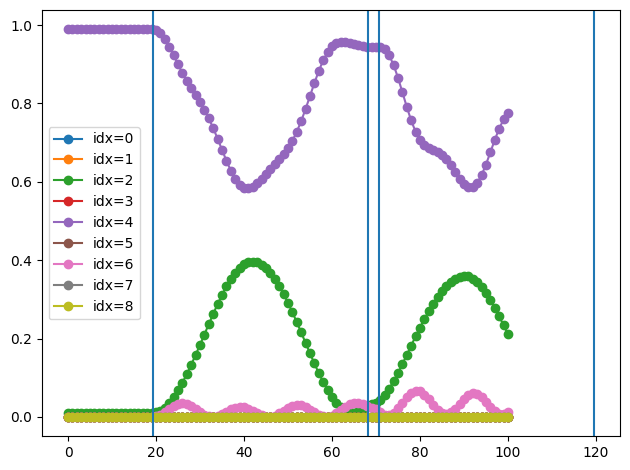

In [42]:
for idx in range(9):
    plt.plot(tsave, result.states[3, :, idx, idx].real, '-o', label=f'{idx=}')
plt.axvline(1.9349107142857144e1)
plt.axvline(1.9349107142857144e1 + 65.15 * 1 / 2)
plt.axvline(1.9349107142857144e1 + 65.15 * 1 / 2 + 2.414131062723352)
plt.axvline(
    1.9349107142857144e1 + 65.15 * 1 / 2 + 2.414131062723352 + 65.15 * 1 / 2
)
plt.legend()
plt.tight_layout()

In [ ]:
result.states[0, :, 4, 4]

In [ ]:
device._eig_inds

In [ ]:
device.get_bare_hamiltonian()

## Plots

In [ ]:
times = jnp.linspace(0, 100, 1001)

In [ ]:
drives_list = []
for qubit in device.qubits:
    for prefactor, operator in qubit.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], '-o')
plt.plot(times, drives_list[1], "-o")
plt.plot(times, drives_list[2], "-o")
plt.plot(times, drives_list[3], "-o")
plt.axhline(0.0, c='tab:gray')
plt.show()

In [ ]:
drives_list = []
for coupling_label, coupling in device._couplings.items():
    for prefactor, operator in coupling.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], "-o")
# plt.axhline(0.0, c="tab:gray")
plt.show()

In [ ]:
drives_list[0]

In [ ]:
test = [
    coupler_pulses.net_zero_transition_coupling_pulse(
        t=t,
        off_coupling=g0,
        on_coupling=g0 + 20 * MHz,
        half_hold_time=65.15 / 2,
        transition_time=2.414131062723352,
        buffer_start=1.9349107142857144e1,
        buffer_end=1.9349107142857144e1,
        gaussian_filter_sigma=0.5,
        transition_coupling=None,
    )
    for t in times
]

In [ ]:
plt.plot(times, test)
plt.axhline(g0)
plt.axhline(g0 + 20*MHz)
plt.axvline(1.9349107142857144e1)
plt.axvline(1.9349107142857144e1 + 65.15 / 2)
plt.axvline(1.9349107142857144e1 + 65.15 / 2 + 2.414131062723352)
# plt.axvline(1.9349107142857144e1)

In [ ]:
t = 0.0
off_coupling=g0
on_coupling=g0 + 20 * MHz
half_hold_time=65.15 / 2
transition_time=2.414131062723352
buffer_start=1.9349107142857144e1
buffer_end=1.9349107142857144e1
gaussian_filter_sigma=0.5
transition_coupling = g0

In [ ]:
from jax.scipy.special import erf

In [ ]:
lengths = jnp.array(
    [
        buffer_start,
        half_hold_time,
        transition_time,
        half_hold_time,
        buffer_end,
    ]
)
couplings = jnp.array(
    [off_coupling, on_coupling, transition_coupling, on_coupling, off_coupling]
)
timescale = 1 / (math.sqrt(2) * gaussian_filter_sigma)
times_drives = jnp.concatenate(
    (
        jnp.zeros(
            1,
        ),
        jnp.cumsum(lengths),
    )
)
erfs = -0.5 * jnp.diff(erf((t - times_drives) * timescale), axis=0)
erfs = erfs / jnp.sum(erfs)
coupling_strength = (erfs * couplings).sum(axis=0)

In [ ]:
erfs

### Coupler drive

In [ ]:
# device._couplings["C_Q1_Q2"].add_drive(
#     label="coupler_cz_Q1_Q2", coupling_pulse=coupler_pulses.capacitive_coupling_pulse
# )

In [ ]:
from typing import Callable
from functools import partial
from blueprint.base import QuantumSystem
from blueprint.qubits import TunableTransmon


def build_capacitive_coupling_pulse_from_flux_drives(
    transmon_1: TunableTransmon,
    transmon_2: TunableTransmon,
    flux_drive_label_1: str,
    flux_drive_label_2: str,
    flux_callable_1: Callable = flux_pulses.net_zero_transition_flux_pulse,
    flux_callable_2: Callable = flux_pulses.net_zero_transition_flux_pulse,
):
    # Only use the params that are set (i.e. not None) in the Drive object.
    flux_drive_1 = transmon_1.drives[flux_drive_label_1]
    not_none_params_1 = {
        key: val for key, val in flux_drive_1.param_vals.items() if val is not None
    }
    partial_func_flux_1 = partial(flux_callable_1, **not_none_params_1)
    # Same for transmon 2
    flux_drive_2 = transmon_2.drives[flux_drive_label_2]
    not_none_params_2 = {
        key: val for key, val in flux_drive_2.param_vals.items() if val is not None
    }
    partial_func_flux_2 = partial(flux_callable_2, **not_none_params_2)

    return partial(
        coupler_pulses.capacitive_coupling_pulse,
        flux_drive_transmon_1=partial_func_flux_1,
        flux_drive_transmon_2=partial_func_flux_2,
        EJ_1=transmon_1._ej,
        EJ_2=transmon_2._ej,
        EC_1=transmon_1._ec,
        EC_2=transmon_2._ec,
        asymm_1=transmon_1._asymm,
        asymm_2=transmon_2._asymm,
        static_ext_flux_1=transmon_1._ext_flux,
        static_ext_flux_2=transmon_2._ext_flux,
    )

In [ ]:
# Only use the params that are set (i.e. not None) in the Drive object.
transmon_1 = device["Q1"]
flux_drive_label_1 = "flux_Q1_cz_Q1_Q2"
flux_callable_1 = flux_pulses.net_zero_transition_flux_pulse

flux_drive_1 = transmon_1.drives[flux_drive_label_1]
not_none_params_1 = {
    key: val for key, val in flux_drive_1.param_vals.items() if val is not None
}
partial_func_flux_1 = partial(flux_callable_1, **not_none_params_1)

In [ ]:
partial_func_flux_1(0.0)

In [ ]:
print(transmon._ext_flux)
print(other_transmon._ext_flux)

In [ ]:
coupler_pulse = build_capacitive_coupling_pulse_from_flux_drives(
    transmon_1=device["Q1"],
    transmon_2=device["Q2"],
    flux_drive_label_1="flux_Q1_cz_Q1_Q2",
    flux_drive_label_2="flux_Q2_cz_Q1_Q2",
    flux_callable_1=flux_pulses.net_zero_transition_flux_pulse,
    flux_callable_2=flux_pulses.net_zero_transition_flux_pulse,
)

In [ ]:
device._couplings["C_Q1_Q2"].add_drive(
    label="coupler_cz_Q1_Q2", coupling_pulse=coupler_pulse
)

In [ ]:
g0 = 7 * MHz / float(transmon.charge_zpf) / float(other_transmon.charge_zpf)
g0

In [ ]:
frequency_resonator=10.0 * GHz
omega_q1 = device["Q1"].fundamental_frequency
omega_q2 = device["Q2"].fundamental_frequency
delta_1 = abs(omega_q1 - frequency_resonator)
delta_2 = abs(omega_q2 - frequency_resonator)
coupling_to_res = math.sqrt(2 * g0 * delta_1 * delta_2 / (delta_1 + delta_2))
coupling_to_res

In [ ]:
coupling_to_res**2 / 2 * (1 / delta_1 + 1 / delta_2)

In [ ]:
g0

In [ ]:
device._couplings["C_Q1_Q2"]._drives["coupler_cz_Q1_Q2"].set_params(
    frequency_resonator=frequency_resonator,
    coupling_res_trans_1=coupling_to_res,
    coupling_res_trans_2=coupling_to_res,
)

In [ ]:
device._couplings["C_Q1_Q2"]._drives["coupler_cz_Q1_Q2"].eval_prefactors(t=0.0)

In [ ]:
for prefactor, operator in device._couplings["C_Q1_Q2"].get_drive_hamiltonian(
    decompose=True
):
    print(prefactor(t=0.0))
    print(operator)

In [ ]:
times = jnp.linspace(0, 100, 1001)

In [ ]:
drives_list = []
for qubit in device.qubits:
    for prefactor, operator in qubit.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], '-o')
plt.plot(times, drives_list[1], "-o")
plt.plot(times, drives_list[2], "-o")
plt.plot(times, drives_list[3], "-o")
plt.axhline(0.0, c='tab:gray')
plt.show()

In [ ]:
drives_list = []
for coupling_label, coupling in device._couplings.items():
    for prefactor, operator in coupling.get_drive_hamiltonian(decompose=True):
        drives_list.append(jnp.array([prefactor(t=t) for t in times]))
len(drives_list)

In [ ]:
plt.plot(times, drives_list[0], "-o")
# plt.axhline(0.0, c="tab:gray")
plt.show()

In [ ]:
device.get_int_hamiltonian()

In [ ]:
device["Q1"].fundamental_frequency

In [ ]:
def compute_freq(ext_flux, asymm, EJ, EC):
    # Do the `compute_eff_josephson_energy()` part
    cos_term = math.cos(ext_flux)
    sqrt_term = math.sqrt(1 + asymm**2 * math.tan(ext_flux) ** 2)
    EJ_effective_1 = EJ * abs(cos_term) * sqrt_term
    # Do the `ext_flux_to_approx_freq()` part
    frequency = math.sqrt(8 * EC * EJ_effective_1) - EC
    return frequency

compute_freq(
    device["Q1"]._ext_flux, device["Q1"]._asymm, device["Q1"]._ej, device["Q1"]._ec)

## Function to build `Hfull: dq.TimeDependentArray` from a device  

In [ ]:
import dynamiqs as dq
from jax import Array
from blueprint.base.terms import Numeric

In [ ]:
def build_dynamiqs_hamiltonian(device: Device):
    dq_hamiltonian = dq.constant(device.get_hamiltonian())
    for qubit in device.qubits:
        drives_iterator = qubit.get_drive_hamiltonian(decompose=True)
        for prefactor, operator in drives_iterator:

            def dq_func(t: float) -> Array:
                return jnp.array([prefactor(t=t)])

            print(dq_func(t=0.0))
            dq_hamiltonian = dq_hamiltonian + dq.modulated(
                dq_func,
                operator,
                # args=(,),
            )

    for coupling_label, coupling in device._couplings.items():
        drives_iterator = coupling.get_drive_hamiltonian(decompose=True)
        for prefactor, operator in drives_iterator:

            def dq_func(t: float) -> Array:
                return jnp.array([prefactor(t=t)])

            # print(prefactor.free_params)
            print(dq_func(t=0.0))
            dq_hamiltonian = dq_hamiltonian + dq.modulated(
                dq_func,
                operator,
                # args=(,),
            )
    return dq_hamiltonian

In [ ]:
full_hamiltonian = build_dynamiqs_hamiltonian(device=device)

In [ ]:
full_hamiltonian(0.0)

In [ ]:
full_hamiltonian(t=20.0).shape

In [ ]:
jnp.allclose(full_hamiltonian(0.0)[0], device.get_hamiltonian())

In [ ]:
print(full_hamiltonian(0.0)[0])

In [ ]:
print(device.get_hamiltonian())

In [ ]:
import qutip

In [ ]:
qutip.Qobj(np.array(full_hamiltonian(0.0)[0]))

In [ ]:
qutip.Qobj(np.array(device.get_hamiltonian()))

In [ ]:
device.qubits[0].drives

In [ ]:
device._couplings["C_Q1_Q2"]._drives

In [ ]:
from functools import partial

In [ ]:
device["Q1"].drives["flux_Q1_cz_Q1_Q2"]

In [ ]:
device["Q1"].drives["flux_Q1_cz_Q1_Q2"].param_vals

In [ ]:
partial_func = partial(
    flux_pulses.net_zero_transition_flux_pulse,
    hold_first_voltage=-0.255,
    transition_voltage=0.0,
    half_hold_time=65.15 / 2,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=9.817191999999999,
    gaussian_filter_sigma=0.5,
)

In [ ]:
partial_func(20.0)

In [ ]:
device["Q1"].drives["flux_Q1_cz_Q1_Q2"]._prefactor_terms

In [ ]:
print(device["Q1"].drives["flux_Q1_cz_Q1_Q2"]._prefactor_terms[0](t=1.0))

In [ ]:
generator = device["Q1"].drives["flux_Q1_cz_Q1_Q2"].eval_prefactors()
generator

In [ ]:
for thing in generator:
    print(thing(1.0))

In [ ]:
device._couplings["C_Q1_Q2"]._drives["coupler_cz_Q1_Q2"].set_params(
    transmon_1=transmon,
    transmon_2=other_transmon,
    applied_flux_1
)

In [ ]:
# dt_ns = 0.5
# cz_pulse_params = {
#     "amplitude": -0.255,
#     "amplitude2": 0.4163522432365655,
#     "aux_pulses_list": [],
#     "buffer_length_end": 1.9349107142857144e1,
#     "buffer_length_start": 1.9349107142857144e1,
#     "gaussian_filter_sigma": 5e-1,
#     "pulse_length": 6.515000000000002e1,
#     "pulse_type": "NZTransitionControlledPulse",
#     "tqg_freq": 4.663912492557016,
#     "tqg_freq2": 4.670220582552401,
#     "trans_length": 2.414131062723352,
#     "V_per_phi0_1": 9.817191999999999,
#     "V_per_phi0_2": 9.90753,
# }